# Ordinary Kriging — 2D vs 3D TPS Monthly Normals Experiment

**Goal:** quantify how much 3D thin-plate spline (TPS) interpolation of monthly climatological normals — using $(x, y, z_{\text{elev}})$ — improves prediction quality over the 2D variant in $(x, y)$ alone.

**Setup**
- Winning combo only: `transform='none'` × `variogram_model='exponential'` (from `kriging_eval.ipynb`).
- 5-fold CV (same `fold_assignment.parquet` shared with LGBM/BayesNF).
- Restricted date window (default 2022–2023) — keeps runtime to a few minutes per fold.
- Reuses pre-computed 2D and 3D normals stored in `fold{k}_norms_at_test_points.pkl` on S3.
- Same prediction worker (`predict_one_day_all_combos`) called twice per day: once with `use_3d_norms=False` (2D) and once with `True` (3D).

**Outputs**
- Per-record predictions: `outputs/kriging/tps_experiment/predictions.parquet` (column `tps_mode ∈ {2D, 3D}`)
- Aggregated metrics: `outputs/kriging/tps_experiment/metrics.csv`
- Uploaded to `s3://thesis-data-ismaktam/kriging/tps_experiment/`


## 0. Imports + paths

In [1]:
import os, sys, gc, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import boto3
import properscoring as ps
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

_NB = Path.cwd()
while _NB != _NB.parent and not (_NB / 'pyproject.toml').exists():
    _NB = _NB.parent
if str(_NB / 'src') not in sys.path:
    sys.path.insert(0, str(_NB / 'src'))
os.chdir(_NB)
print(f'Project root: {_NB}')

Project root: /Users/etomengoi/Desktop/precip_interpolation_thesis


## 1. Constants

In [2]:
RANDOM_SEED = 42
K_FOLDS     = 5
K_MC        = 100
N_JOBS      = int(os.environ.get('N_JOBS', '-1'))

# Date window (smaller = faster). Set None for full record.
DATE_START = '2022-01-01'
DATE_END   = '2023-12-31'

# Winning combo from kriging_eval (used as default)
WIN_TRANSFORM = 'none'
WIN_VARIOGRAM = 'exponential'

# ── Paths ────────────────────────────────────────────────────────────────
OUT_DIR    = Path('outputs/kriging')
EXP_DIR    = OUT_DIR / 'tps_experiment'
NORMS_DIR  = OUT_DIR / 'monthly_norms'
for d in (OUT_DIR, EXP_DIR, NORMS_DIR):
    d.mkdir(parents=True, exist_ok=True)

S3_BUCKET = 'thesis-data-ismaktam'
S3_ROOT   = 'kriging'
FOLD_S3   = 'lgbm/fold_assignment.parquet'

FORCE_RECOMPUTE = False

print(f'Window: {DATE_START} → {DATE_END}')
print(f'Combo:  {WIN_TRANSFORM} × {WIN_VARIOGRAM}')
print(f'N_JOBS={N_JOBS}  K_FOLDS={K_FOLDS}')

Window: 2022-01-01 → 2023-12-31
Combo:  none × exponential
N_JOBS=-1  K_FOLDS=5


## 2. S3 helpers

In [3]:
s3 = boto3.client('s3')

def s3_exists(s3_key):
    try:
        s3.head_object(Bucket=S3_BUCKET, Key=s3_key); return True
    except Exception:
        return False

def s3_upload(local_path, s3_key):
    s3.upload_file(str(local_path), S3_BUCKET, s3_key)
    print(f'  ↑ s3://{S3_BUCKET}/{s3_key}')

def s3_download(s3_key, local_path):
    try:
        local_path.parent.mkdir(parents=True, exist_ok=True)
        s3.download_file(S3_BUCKET, s3_key, str(local_path))
        print(f'  ↓ s3://{S3_BUCKET}/{s3_key}')
        return True
    except Exception:
        return False

def fetch(s3_key, local_path):
    if local_path.exists() and not FORCE_RECOMPUTE:
        return True
    if FORCE_RECOMPUTE:
        return False
    return s3_download(s3_key, local_path)

## 3. Load data + fit transform pipeline

Same routine as `kriging_train.ipynb` cell #8. Loads the full 1961–2023 record so the climatological monthly normals (and NST CDF, etc.) are fitted on the entire training data — the experiment then restricts only the *prediction* loop to the chosen window.

In [4]:
from thesis.config import Config
from thesis.data.registry import DataRegistry
from thesis.scripts._common import load_and_fit_pipeline

cfg      = Config()
registry = DataRegistry.from_config(cfg)

all_raw, all_proc, fwd, inv, proc_by_date, _ = load_and_fit_pipeline(
    cfg, registry, cfg.date_start, cfg.date_end,
)
print(f'all_proc rows : {len(all_proc):,}')
print(f'unique stations: {all_proc["station_id"].nunique()}  (492 holdout already excluded)')

[18:28:47] Loading raw data: 1961-01-01 … 2023-12-31
[18:29:02]   45,237,660 rows, 1966 stations
[18:29:02] Fitting base pipeline: Projection → Indicator → Detrend
[18:29:21]   Fitting NormalScoreTransform…
[18:29:22]   NormalScoreTransform CDF: 17,409,376 wet quotas
all_proc rows : 45,237,660
unique stations: 1966  (492 holdout already excluded)


## 4. Load fold assignment + global variogram

In [5]:
FOLD_LOCAL = OUT_DIR / 'fold_assignment.parquet'
if not fetch(FOLD_S3, FOLD_LOCAL):
    raise FileNotFoundError(f'fold_assignment.parquet not in S3 at {FOLD_S3}')
fold_assignment = pd.read_parquet(FOLD_LOCAL)
fold_map = dict(zip(fold_assignment['station_id'], fold_assignment['fold']))
all_proc['fold'] = all_proc['station_id'].map(fold_map).astype('Int64')
print(f'Stations with fold assigned: {all_proc["fold"].notna().sum():,}')
print(fold_assignment['fold'].value_counts().sort_index().to_string())

VGM_LOCAL = OUT_DIR / 'global_variogram.pkl'
if not fetch(f'{S3_ROOT}/global_variogram.pkl', VGM_LOCAL):
    raise FileNotFoundError('global_variogram.pkl not on S3 — run kriging_train.ipynb first')
with open(VGM_LOCAL, 'rb') as f:
    payload = pickle.load(f)
global_vgm = payload['variograms'] if isinstance(payload, dict) and 'variograms' in payload else payload
params = global_vgm[(WIN_TRANSFORM, WIN_VARIOGRAM)]['params_dict']
print(f'\nWinning combo variogram: {WIN_TRANSFORM} × {WIN_VARIOGRAM}')
print(f'  nugget={params["nugget"]:.4f}  psill={params["psill"]:.4f}  range={params["range"]/1000:.0f} km')

Stations with fold assigned: 45,237,660
fold
0    394
1    393
2    393
3    393
4    393

Winning combo variogram: none × exponential
  nugget=0.0003  psill=0.0078  range=79 km


## 5. Restrict to experiment window

In [6]:
exp_dates = [d for d in sorted(proc_by_date.keys()) if DATE_START <= d <= DATE_END]
print(f'Experiment days: {len(exp_dates):,}  ({exp_dates[0]} → {exp_dates[-1]})')

Experiment days: 730  (2022-01-01 → 2023-12-31)


## 6. K-fold prediction loop — both TPS modes

For each fold k and each day, calls `predict_one_day_all_combos` twice:
- Once with `use_3d_norms=False` → uses pre-computed `norms_2d`
- Once with `use_3d_norms=True` → uses pre-computed `norms_3d`

Only the winning (transform, variogram_model) combination is computed.

In [7]:
from thesis.models.kriging.kfold_worker import predict_one_day_all_combos

MAX_WET        = cfg.kriging.max_wet
N_STATIONS_MIN = cfg.kriging.n_stations_min
TRANSFORMS_W   = [WIN_TRANSFORM]
VGM_MODELS_W   = [WIN_VARIOGRAM]

# Rebuild proc_by_date AFTER fold column was added to all_proc (cell 10) —
# the dict returned by load_and_fit_pipeline doesn't carry the new column.
proc_by_date = {str(d): grp for d, grp in all_proc.groupby('date')}

all_results = []
for k in range(K_FOLDS):
    norms_local = NORMS_DIR / f'fold{k}_norms_at_test_points.pkl'
    if not fetch(f'{S3_ROOT}/monthly_norms/fold{k}_norms_at_test_points.pkl', norms_local):
        raise RuntimeError(f'Fold {k} norms missing on S3 — run kriging_train.ipynb cell 6 first')
    with open(norms_local, 'rb') as f:
        fold_norms = pickle.load(f)
    test_sids = fold_norms['station_ids']
    norms_2d  = fold_norms['norms_2d']
    norms_3d  = fold_norms['norms_3d']
    test_sid_to_idx = {s: i for i, s in enumerate(test_sids)}

    # Build (date, train_d, test_d, n2d, n3d) tuples for this fold
    proc_train_test = []
    for date in exp_dates:
        proc_d = proc_by_date[date]
        is_test = proc_d['fold'] == k
        proc_test_d  = proc_d[is_test]
        proc_train_d = proc_d[~is_test]
        if len(proc_test_d) == 0:
            continue
        test_idx = np.array([test_sid_to_idx[s] for s in proc_test_d['station_id'].values])
        n2d_today = norms_2d[:, test_idx]
        n3d_today = norms_3d[:, test_idx]
        proc_train_test.append((date, proc_train_d, proc_test_d, n2d_today, n3d_today))
    print(f'\n[fold {k}] {len(proc_train_test)} valid days')

    for tps_mode_label, use_3d in [('2D', False), ('3D', True)]:
        print(f'  → predicting tps_mode={tps_mode_label}...')
        fold_results = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
            delayed(predict_one_day_all_combos)(
                date, proc_train_d, proc_test_d,
                global_vgm, TRANSFORMS_W, VGM_MODELS_W,
                fwd, inv, n2d_today, n3d_today,
                N_STATIONS_MIN, MAX_WET, K_MC, RANDOM_SEED,
                use_3d,
            )
            for date, proc_train_d, proc_test_d, n2d_today, n3d_today in proc_train_test
        )
        fold_df = pd.concat([df for df in fold_results if not df.empty], ignore_index=True)
        fold_df['fold'] = k
        fold_df['tps_mode'] = tps_mode_label
        all_results.append(fold_df)
        print(f'    {len(fold_df):,} records')
    del fold_results, fold_df, proc_train_test
    gc.collect()

predictions_df = pd.concat(all_results, ignore_index=True)
out_local = EXP_DIR / 'predictions.parquet'
predictions_df.to_parquet(out_local, index=False)
print(f'\nTotal records: {len(predictions_df):,}')
print(f'Saved → {out_local}')
s3_upload(out_local, f'{S3_ROOT}/tps_experiment/predictions.parquet')


[fold 0] 730 valid days
  → predicting tps_mode=2D...
    287,620 records
  → predicting tps_mode=3D...
    287,620 records
  ↓ s3://thesis-data-ismaktam/kriging/monthly_norms/fold1_norms_at_test_points.pkl

[fold 1] 730 valid days
  → predicting tps_mode=2D...
    286,890 records
  → predicting tps_mode=3D...
    286,890 records
  ↓ s3://thesis-data-ismaktam/kriging/monthly_norms/fold2_norms_at_test_points.pkl

[fold 2] 730 valid days
  → predicting tps_mode=2D...
    286,890 records
  → predicting tps_mode=3D...
    286,890 records
  ↓ s3://thesis-data-ismaktam/kriging/monthly_norms/fold3_norms_at_test_points.pkl

[fold 3] 730 valid days
  → predicting tps_mode=2D...
    286,890 records
  → predicting tps_mode=3D...
    286,890 records
  ↓ s3://thesis-data-ismaktam/kriging/monthly_norms/fold4_norms_at_test_points.pkl

[fold 4] 730 valid days
  → predicting tps_mode=2D...
    286,890 records
  → predicting tps_mode=3D...
    286,890 records

Total records: 2,870,360
Saved → outputs/k

## 7. Aggregate metrics

Two metric sets:
1. **All predictions** — every (station, day) record
2. **Predicted-wet only** (`predicted_mm ≥ 0.4`) — matches the convention used in `kriging_eval.ipynb`

In [8]:
def _metrics(grp):
    obs  = grp['observed_mm'].values
    pred = grp['predicted_mm'].values
    sd   = np.sqrt(np.maximum(grp['predicted_var_mm2'].values, 1e-8))
    return {
        'crps': float(np.mean(ps.crps_gaussian(obs, mu=pred, sig=sd))),
        'mae':  float(np.mean(np.abs(obs - pred))),
        'rmse': float(np.sqrt(np.mean((obs - pred) ** 2))),
        'n':    int(len(grp)),
    }

rows_all, rows_pw = [], []
PRED_WET = 0.4
for (k, mode), grp in predictions_df.groupby(['fold', 'tps_mode']):
    rows_all.append({'fold': k, 'tps_mode': mode, **_metrics(grp)})
    pw = grp[grp['predicted_mm'] >= PRED_WET]
    if len(pw) == 0:
        continue
    rows_pw.append({'fold': k, 'tps_mode': mode, **_metrics(pw)})

metrics_all = pd.DataFrame(rows_all)
metrics_pw  = pd.DataFrame(rows_pw)

summary_all = metrics_all.groupby('tps_mode')[['crps', 'mae', 'rmse']].agg(['mean', 'std']).round(4)
summary_pw  = metrics_pw.groupby('tps_mode')[['crps', 'mae', 'rmse']].agg(['mean', 'std']).round(4)

print('=== ALL PREDICTIONS — mean ± std across folds ===')
print(summary_all.to_string())
print()
print('=== PREDICTED-WET ONLY (predicted_mm ≥ 0.4) — mean ± std across folds ===')
print(summary_pw.to_string())

summary_all.to_csv(EXP_DIR / 'metrics_all.csv')
summary_pw.to_csv(EXP_DIR / 'metrics_predwet.csv')
for f in ['metrics_all.csv', 'metrics_predwet.csv']:
    s3_upload(EXP_DIR / f, f'{S3_ROOT}/tps_experiment/{f}')

=== ALL PREDICTIONS — mean ± std across folds ===
            crps             mae            rmse        
            mean     std    mean     std    mean     std
tps_mode                                                
2D        0.3183  0.0057  0.3854  0.0080  1.0552  0.0267
3D        0.2973  0.0065  0.3508  0.0091  0.9717  0.0222

=== PREDICTED-WET ONLY (predicted_mm ≥ 0.4) — mean ± std across folds ===
            crps             mae            rmse        
            mean     std    mean     std    mean     std
tps_mode                                                
2D        0.7143  0.0117  0.8774  0.0182  1.6259  0.0428
3D        0.6633  0.0124  0.7932  0.0191  1.4941  0.0338
  ↑ s3://thesis-data-ismaktam/kriging/tps_experiment/metrics_all.csv
  ↑ s3://thesis-data-ismaktam/kriging/tps_experiment/metrics_predwet.csv


## 8. Visualisation: per-fold CRPS comparison

  ↑ s3://thesis-data-ismaktam/kriging/tps_experiment/tps_comparison.png


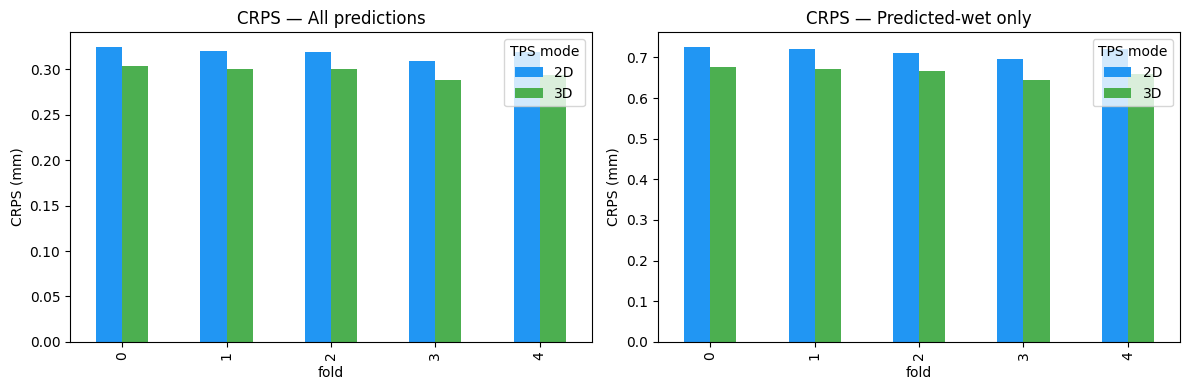

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in [(axes[0], metrics_all, 'All predictions'),
                       (axes[1], metrics_pw,  'Predicted-wet only')]:
    pivot = df.pivot(index='fold', columns='tps_mode', values='crps')
    pivot.plot.bar(ax=ax, color=['#2196F3', '#4CAF50'])
    ax.set_title(f'CRPS — {title}')
    ax.set_xlabel('fold')
    ax.set_ylabel('CRPS (mm)')
    ax.legend(title='TPS mode')
plt.tight_layout()
plt.savefig(EXP_DIR / 'tps_comparison.png', dpi=150, bbox_inches='tight')
s3_upload(EXP_DIR / 'tps_comparison.png', f'{S3_ROOT}/tps_experiment/tps_comparison.png')
plt.show()

## 9. Done — S3 manifest

In [10]:
print('=== S3 ARTEFACTS ===')
for key in ['tps_experiment/predictions.parquet',
            'tps_experiment/metrics_all.csv',
            'tps_experiment/metrics_predwet.csv',
            'tps_experiment/tps_comparison.png']:
    print(f'  s3://{S3_BUCKET}/{S3_ROOT}/{key}  '
          f'{"✓" if s3_exists(f"{S3_ROOT}/{key}") else "✗"}')

=== S3 ARTEFACTS ===
  s3://thesis-data-ismaktam/kriging/tps_experiment/predictions.parquet  ✓
  s3://thesis-data-ismaktam/kriging/tps_experiment/metrics_all.csv  ✓
  s3://thesis-data-ismaktam/kriging/tps_experiment/metrics_predwet.csv  ✓
  s3://thesis-data-ismaktam/kriging/tps_experiment/tps_comparison.png  ✓
